# Módulo 3: Exploración y Análisis de Series Temporales

Este módulo profundiza en la exploración y el análisis de series temporales, cubriendo desde la visualización hasta la identificación de patrones y la preparación de datos para modelos predictivos.

## 1. Visualización de Series Temporales

La visualización es el primer paso crucial para comprender los datos.  Los gráficos permiten identificar tendencias, estacionalidad, ciclos y valores atípicos.

**Gráficos Clave:**

* **Gráfico de líneas:** Muestra la evolución de la variable a lo largo del tiempo. Es fundamental para observar tendencias y patrones generales.
* **Gráfico de dispersión (Scatter plot):**  Útil para analizar la relación entre dos variables a lo largo del tiempo. Puede ayudar a descubrir correlaciones o dependencias.
* **Histograma:** Representa la distribución de los valores de la variable. Ayuda a entender la concentración de los datos y la presencia de valores atípicos.

**Librerías en Python:**

* `matplotlib.pyplot`: Para la creación de gráficos básicos y personalizados.
* `seaborn`: Para visualizaciones más avanzadas y atractivas.


## 2. Descomposición de Series Temporales

La descomposición es una técnica para separar una serie temporal en sus componentes principales:

* **Tendencia:** Movimiento general de la serie a largo plazo (creciente, decreciente o constante).
* **Estacionalidad:** Patrones repetitivos que ocurren a intervalos regulares (diarios, semanales, mensuales, etc.).
* **Ciclos:** fluctuaciones de la serie con una duración mayor que la estacionalidad.
* **Ruido (o componente aleatorio):** Variaciones aleatorias que no siguen un patrón predecible.

**Métodos de Descomposición:**

* **Aditivo:** La serie es la suma de sus componentes (Tendencia + Estacionalidad + Ruido). Se aplica cuando la amplitud de la estacionalidad permanece constante a lo largo del tiempo.
* **Multiplicativo:** La serie es el producto de sus componentes (Tendencia * Estacionalidad * Ruido). Se utiliza cuando la amplitud de la estacionalidad varía con la tendencia.


**Librerías en Python:**

* `statsmodels`: Ofrece funciones para la descomposición de series temporales, incluyendo métodos aditivos y multiplicativos.

## 3. Análisis de Componentes

Una vez descompuesta, se puede analizar cada componente individualmente:

* **Tendencia:** Se puede modelar mediante regresión lineal, polinomial u otros métodos para predecir su comportamiento futuro.
* **Estacionalidad:** Se puede analizar su periodicidad y amplitud para entender su impacto en la serie.
* **Ruido:** Representa la aleatoriedad inherente a la serie. Se puede medir su variabilidad para estimar la incertidumbre en las predicciones.


## 4. Autocorrelación

La autocorrelación mide la correlación de una serie temporal consigo misma en diferentes puntos del tiempo.

**Autocorrelación completa (ACF):**  Mide la correlación entre los valores de la serie y sus valores pasados.
**Autocorrelación parcial (PACF):** Mide la correlación entre los valores de la serie y sus valores pasados, eliminando el efecto de las correlaciones intermedias.

**Interpretación de ACF y PACF:**

*  **ACF:** Indica la correlación directa entre la serie y sus retrasos.
* **PACF:** Muestra la correlación entre la serie y un retraso específico, eliminando el efecto de los retrasos intermedios.
* Cortes abruptos en la función de autocorrelación y/o autocorrelación parcial (PACF) señalan importantes retrasos a considerar en un modelo autorregresivo.

**Funciones `acf` y `pacf` (statsmodels):**

Estas funciones calculan y grafican las funciones de autocorrelación y autocorrelación parcial. La interpretación de los gráficos permite identificar los órdenes p y q para los modelos ARIMA.

**Aplicaciones en Modelos:**

ACF y PACF son esenciales para determinar los parámetros de modelos autorregresivos (AR), de media móvil (MA), y autorregresivo integrado de media móvil (ARIMA), usados para pronósticos.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd


data_path = '/content/drive/MyDrive/datasets/Modulo3/'

try:
  df_auto = pd.read_csv(data_path + 'autoregresivo_serie_temporal.csv', index_col='Fecha')
  df_descomp = pd.read_csv(data_path + 'decomposicion_serie_temporal.csv', index_col='Fecha')
  df_trend = pd.read_csv(data_path + 'tendencia_estacionalidad_serie_temporal.csv', index_col='Fecha')
  df_sales = pd.read_csv(data_path + 'Sales_Data.csv', index_col='Date')
  df_traffic = pd.read_csv(data_path + 'Traffic_Data.csv', index_col='Date')


  print("Datasets cargados correctamente.")
except FileNotFoundError:
  print("Error: Uno o más archivos no se encontraron. Verifica la ruta especificada.")
except pd.errors.ParserError:
  print("Error: Error al analizar los datos. Verifica el formato de tus archivos CSV.")
except Exception as e:
  print(f"Ocurrió un error inesperado: {e}")



for df in [df_auto, df_descomp, df_trend]:
  if 'Fecha' in df.columns:
    df['Fecha'] = pd.to_datetime(df['Fecha'])
    df = df.set_index('Fecha')

Datasets cargados correctamente.


In [ ]:
df_traffic.head()

,Page_A_Traffic,Page_B_Traffic
Date,,
2022-01-01,965.0,901.0
2022-01-02,966.0,872.0
2022-01-03,1037.0,988.0
2022-01-04,1029.0,975.0
2022-01-05,973.0,971.0


In [ ]:
import matplotlib.pyplot as plt

# Cambia el estilo
plt.style.use('ggplot')

In [ ]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

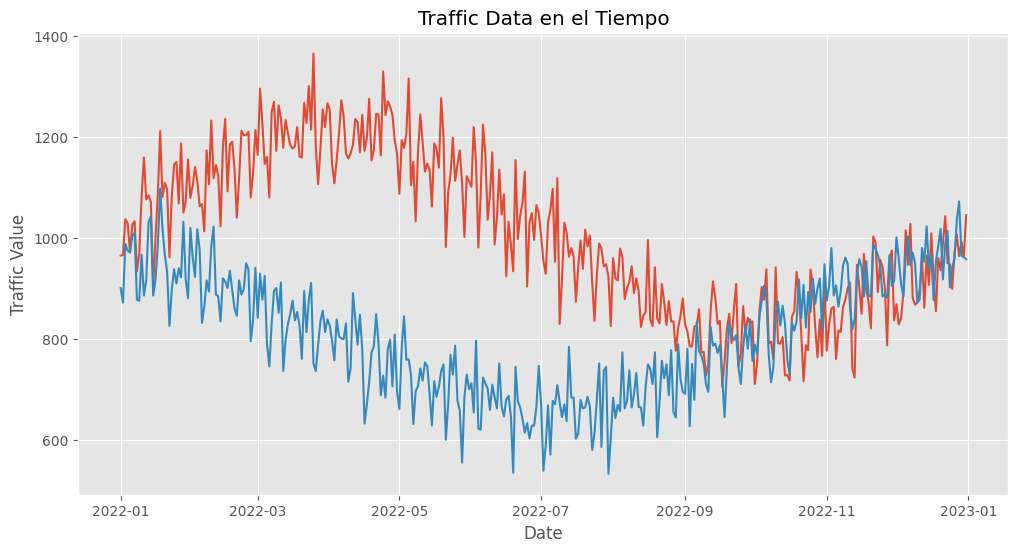

In [ ]:
import matplotlib.pyplot as plt


if 'df_traffic' in locals() and not df_traffic.empty:
  if not pd.api.types.is_datetime64_any_dtype(df_traffic.index):
    df_traffic.index = pd.to_datetime(df_traffic.index)

  # Plotting the line chart
  plt.figure(figsize=(12, 6))
  plt.plot(df_traffic.index, df_traffic['Page_A_Traffic'])
  plt.plot(df_traffic.index, df_traffic['Page_B_Traffic'])
  plt.xlabel("Date")
  plt.ylabel("Traffic Value")
  plt.title("Traffic Data en el Tiempo")
  plt.grid(True)
  plt.show()
else:
  print("Error: 'df_traffic' DataFrame no existe.")

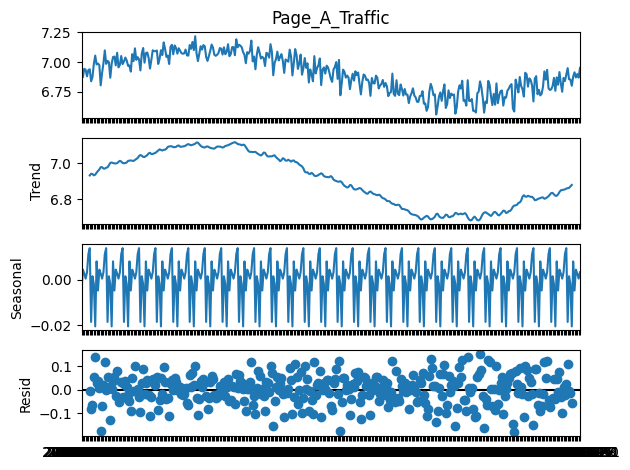

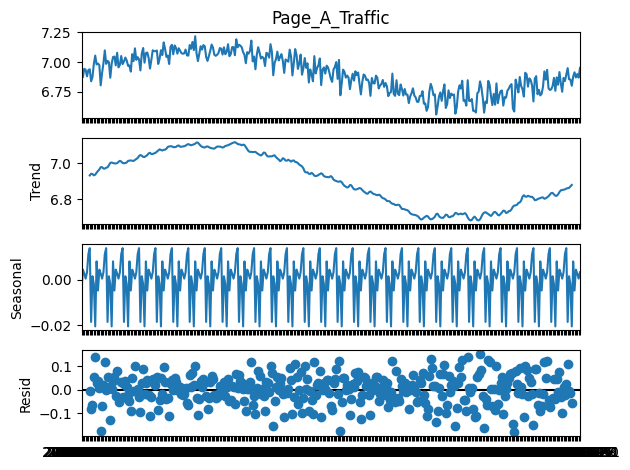

In [ ]:
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

y_log = np.log(df_traffic['Page_A_Traffic'])
df_traffic['log_Page_A_Traffic'] = y_log

decomp_y = seasonal_decompose(y_log, model='additive', period=12)
decomp_y.plot()

#como la gráfica de residuos no tienen ningun patron, es aditivo



### Análisis Visual de Patrones

In [ ]:
df_sales.head()

,Product_A_Sales,Product_B_Sales
Date,,
2020-01-31,510.0,435.0
2020-02-29,522.0,400.0
2020-03-31,556.0,420.0
2020-04-30,580.0,394.0
2020-05-31,539.0,375.0


In [ ]:
df_sales.index = pd.to_datetime(df_sales.index)

In [ ]:
frecuencia = pd.infer_freq(df_sales.index)
frecuencia

'ME'

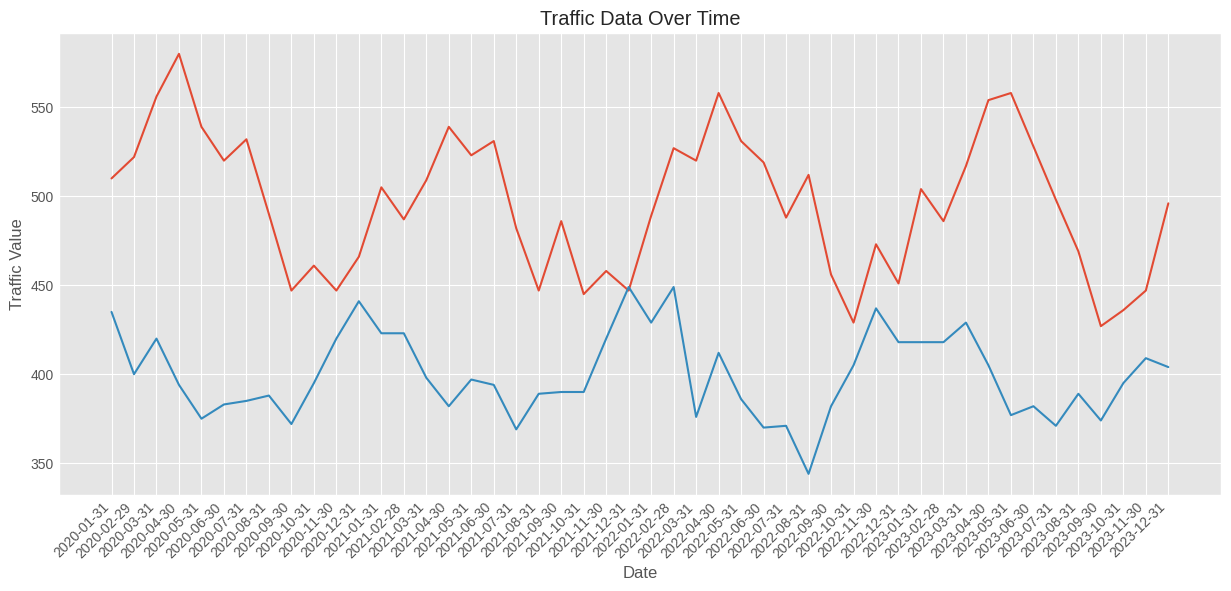

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(df_sales.index, df_sales['Product_A_Sales'])
plt.plot(df_sales.index, df_sales['Product_B_Sales'])
plt.xlabel("Date")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Traffic Value")
plt.title("Traffic Data Over Time")
plt.grid(True)
plt.show()

# Series de Tiempo: Modelos Autoregresivos y Descomposición

## 1. ¿Qué es una serie autoregresiva?

Una **serie autoregresiva** es un modelo utilizado en el análisis de series de tiempo que intenta predecir el valor futuro de una variable utilizando sus propios valores pasados.

### Concepto clave:
- **Autoregresiva** significa que el valor actual de la serie depende de sus valores anteriores.
- Por ejemplo, si tienes datos de temperaturas diarias, una serie autoregresiva podría usar las temperaturas de los últimos días para predecir la temperatura del día siguiente.

### Notación:
Un modelo autoregresivo de orden `p` (denotado como **AR(p)**) utiliza los `p` valores previos para hacer la predicción. La fórmula general sería algo como esto:

$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \epsilon_t
$$

Donde:
- $ y_t $: Es el valor que queremos predecir en el tiempo $ t $.
- $ c $: Es una constante (un valor base).
- $ \phi_1, \phi_2, \dots, \phi_p $: Son los coeficientes que determinan cuánto influyen los valores pasados.
- $ y_{t-1}, y_{t-2}, \dots, y_{t-p} $: Son los valores previos de la serie.
- $ \epsilon_t $: Es un término de error o ruido aleatorio en el tiempo $ t $.

---

## 2. Modelos Aditivos y Multiplicativos en la Descomposición de Series

Cuando trabajas con series de tiempo, muchas veces intentas **descomponer** la serie en partes más simples para entender mejor su comportamiento. Dos enfoques comunes son los **modelos aditivos** y **multiplicativos**. La diferencia principal está en cómo se combinan las componentes de la serie (tendencia, estacionalidad y residuos).

---

### 2.1 Modelo Aditivo

En un modelo aditivo, las diferentes componentes de la serie (tendencia, estacionalidad y residuos) **se suman** entre sí.

$$
\text{Valor observado} = \text{Tendencia} + \text{Estacionalidad} + \text{Residuos}
$$

#### Ejemplo:
Imagina que tienes una serie de ventas mensuales:
- La tendencia indica un crecimiento general de 5 unidades por mes.
- La estacionalidad añade 3 unidades más en diciembre debido a las compras navideñas.
- Los residuos son pequeñas fluctuaciones aleatorias.

Entonces, el valor observado en diciembre sería algo como:  
$$
\text{Valor} = (\text{Tendencia}) + (\text{Estacionalidad}) + (\text{Residuos})
$$  
Por ejemplo: $ 50 + 3 + 2 = 55 $.

#### Características:
- Se usa cuando la estacionalidad es **constante** a lo largo del tiempo (no cambia mucho con la tendencia).
- Es más fácil de interpretar porque las componentes son independientes.

---

### 2.2 Modelo Multiplicativo

En un modelo multiplicativo, las componentes **se multiplican** entre sí.

$$
\text{Valor observado} = \text{Tendencia} \times \text{Estacionalidad} \times \text{Residuos}
$$

#### Ejemplo:
Sigamos con el ejemplo de ventas mensuales:
- La tendencia indica un crecimiento general de 50 unidades por mes.
- La estacionalidad multiplica las ventas por 1.2 en diciembre debido a las compras navideñas.
- Los residuos son pequeños factores aleatorios.

Entonces, el valor observado en diciembre sería algo como:  
$$
\text{Valor} = (\text{Tendencia}) \times (\text{Estacionalidad}) \times (\text{Residuos})
$$  
Por ejemplo: $ 50 \times 1.2 \times 1.1 = 66 $.

#### Características:
- Se usa cuando la estacionalidad **crece o decrece proporcionalmente** con la tendencia.
- Es más común en datos donde los efectos estacionales son más fuertes a medida que la tendencia aumenta.

---

### Comparación simple:

| **Aspecto**              | **Modelo Aditivo**                     | **Modelo Multiplicativo**               |
|--------------------------|----------------------------------------|-----------------------------------------|
| **Fórmula**              | Suma de componentes                   | Multiplicación de componentes           |
| **Estacionalidad**       | Constante (no cambia con la tendencia) | Proporcional (crece con la tendencia)   |
| **Uso típico**           | Datos con patrones lineales           | Datos con patrones exponenciales        |
| **Interpretación**       | Más fácil                             | Más compleja                            |

---

### Resumen:
- Usa un **modelo aditivo** si la estacionalidad es constante y no depende de la magnitud de la tendencia.
- Usa un **modelo multiplicativo** si la estacionalidad varía con la tendencia (por ejemplo, si los picos estacionales son más grandes a medida que la serie crece).

## Ejemplo en Plots

In [ ]:
# Importar las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from IPython.display import display

# Función para generar una serie aditiva
def generate_additive_series(t, trend, seasonality, noise, smoothness):
    """
    Genera una serie temporal aditiva.
    - t: Tiempo (array)
    - trend: Tendencia (función)
    - seasonality: Estacionalidad (función)
    - noise: Ruido aleatorio
    - smoothness: Controla la suavidad del ruido
    """
    return trend(t) + seasonality(t) + noise * np.random.normal(size=len(t)) * smoothness

# Función para generar una serie multiplicativa
def generate_multiplicative_series(t, trend, seasonality, noise, smoothness):
    """
    Genera una serie temporal multiplicativa.
    - t: Tiempo (array)
    - trend: Tendencia (función)
    - seasonality: Estacionalidad (función)
    - noise: Ruido aleatorio
    - smoothness: Controla la suavidad del ruido
    """
    return trend(t) * seasonality(t) * (1 + noise * np.random.normal(size=len(t)) * smoothness)

# Definir funciones para la tendencia y estacionalidad
def trend(t):
    return 0.1 * t  # Una tendencia lineal creciente

def seasonality(t):
    return np.sin(2 * np.pi * t / 50)  # Una estacionalidad sinusoidal con período de 50 unidades

# Configuración inicial
np.random.seed(42)  # Fijar semilla para reproducibilidad
t = np.arange(0, 200)  # Tiempo de 0 a 200
noise_level = 0.1  # Nivel base de ruido

# Función para graficar ambas series con un slider
def plot_series(smoothness):
    # Generar las series
    additive_series = generate_additive_series(t, trend, seasonality, noise_level, smoothness)
    multiplicative_series = generate_multiplicative_series(t, trend, seasonality, noise_level, smoothness)

    # Crear la figura
    plt.figure(figsize=(12, 6))

    # Graficar la serie aditiva
    plt.subplot(2, 1, 1)
    plt.plot(t, additive_series, label="Serie Aditiva", color="blue")
    plt.title("Modelo Aditivo")
    plt.legend()

    # Graficar la serie multiplicativa
    plt.subplot(2, 1, 2)
    plt.plot(t, multiplicative_series, label="Serie Multiplicativa", color="orange")
    plt.title("Modelo Multiplicativo")
    plt.legend()

    # Ajustar el diseño
    plt.tight_layout()
    plt.show()

# Crear un slider interactivo
smoothness_slider = FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description="Suavidad:")
interact(plot_series, smoothness=smoothness_slider)

interactive(children=(FloatSlider(value=1.0, description='Suavidad:', max=2.0, min=0.1), Output()), _dom_class…

<function __main__.plot_series(smoothness)>

In [ ]:
# Importar las librerías necesarias
import numpy as np
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import column
from bokeh.models import Slider, CustomJS
output_notebook()  # Necesario para mostrar gráficos en Colab o Jupyter

# Función para generar una serie aditiva
def generate_additive_series(t, trend, seasonality, noise, smoothness):
    """
    Genera una serie temporal aditiva.
    - t: Tiempo (array)
    - trend: Tendencia (función)
    - seasonality: Estacionalidad (función)
    - noise: Ruido aleatorio
    - smoothness: Controla la suavidad del risco
    """
    return trend(t) + seasonality(t) + noise * np.random.normal(size=len(t)) * smoothness

# Función para generar una serie multiplicativa
def generate_multiplicative_series(t, trend, seasonality, noise, smoothness):
    """
    Genera una serie temporal multiplicativa.
    - t: Tiempo (array)
    - trend: Tendencia (función)
    - seasonality: Estacionalidad (función)
    - noise: Ruido aleatorio
    - smoothness: Controla la suavidad del ruido
    """
    return trend(t) * seasonality(t) * (1 + noise * np.random.normal(size=len(t)) * smoothness)

# Definir funciones para la tendencia y estacionalidad
def trend(t):
    return 0.1 * t  # Una tendencia lineal creciente

def seasonality(t):
    return np.sin(2 * np.pi * t / 50)  # Una estacionalidad sinusoidal con período de 50 unidades

# Configuración inicial
np.random.seed(42)  # Fijar semilla para reproducibilidad
t = np.arange(0, 200)  # Tiempo de 0 a 200
noise_level = 0.1  # Nivel base de ruido

# Generar datos iniciales
smoothness = 1.0
additive_series = generate_additive_series(t, trend, seasonality, noise_level, smoothness)
multiplicative_series = generate_multiplicative_series(t, trend, seasonality, noise_level, smoothness)

# Crear la figura de Bokeh
p1 = figure(title="Modelo Aditivo", x_axis_label="Tiempo", y_axis_label="Valor", width=800, height=300)
p2 = figure(title="Modelo Multiplicativo", x_axis_label="Tiempo", y_axis_label="Valor", width=800, height=300)

# Graficar las series iniciales
line1 = p1.line(t, additive_series, legend_label="Serie Aditiva", line_color="blue")
line2 = p2.line(t, multiplicative_series, legend_label="Serie Multiplicativa", line_color="orange")

# Crear un slider
slider = Slider(start=0.1, end=2.0, value=1.0, step=0.1, title="Suavidad")

# Agregar interactividad con JavaScript
callback = CustomJS(args=dict(line1=line1, line2=line2, t=t, noise_level=noise_level), code="""
    const smoothness = cb_obj.value;
    const noise = %s;
    const trend = t => 0.1 * t;
    const seasonality = t => Math.sin(2 * Math.PI * t / 50);

    // Calcular nueva serie aditiva
    const additive_series = t.map(i => trend(i) + seasonality(i) + noise * (Math.random() - 0.5) * smoothness);
    line1.data_source.data['y'] = additive_series;

    // Calcular nueva serie multiplicativa
    const multiplicative_series = t.map(i => trend(i) * seasonality(i) * (1 + noise * (Math.random() - 0.5) * smoothness));
    line2.data_source.data['y'] = multiplicative_series;

    // Actualizar gráficos
    line1.data_source.change.emit();
    line2.data_source.change.emit();
""" % noise_level)

slider.js_on_change('value', callback)

# Mostrar el layout
layout = column(slider, p1, p2)
show(layout)

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Definir funciones para la tendencia y estacionalidad
def trend(t):
    return 0.1 * t  # Una tendencia lineal creciente

def seasonality(t):
    return np.sin(2 * np.pi * t / 50)  # Una estacionalidad sinusoidal con período de 50 unidades

# Configuración inicial
np.random.seed(42)  # Fijar semilla para reproducibilidad
t = np.arange(0, 200)  # Tiempo de 0 a 200
noise_level = 0.1  # Nivel base de ruido

# Función para generar series
def generate_series(t, trend, seasonality, noise, smoothness, model='additive'):
    if model == 'additive':
        return trend(t) + seasonality(t) + noise * np.random.normal(size=len(t)) * smoothness
    elif model == 'multiplicative':
        return trend(t) * seasonality(t) * (1 + noise * np.random.normal(size=len(t)) * smoothness)

# Crear figura con subplots
fig = make_subplots(rows=2, cols=1, subplot_titles=("Modelo Aditivo", "Modelo Multiplicativo"))

# Agregar trazas iniciales
smoothness = 1.0
additive_series = generate_series(t, trend, seasonality, noise_level, smoothness, model='additive')
multiplicative_series = generate_series(t, trend, seasonality, noise_level, smoothness, model='multiplicative')

fig.add_trace(go.Scatter(x=t, y=additive_series, name="Serie Aditiva"), row=1, col=1)
fig.add_trace(go.Scatter(x=t, y=multiplicative_series, name="Serie Multiplicativa"), row=2, col=1)

# Ajustar diseño
fig.update_layout(height=800, width=800, title_text="Series de Tiempo: Modelos Aditivo y Multiplicativo")

# Agregar slider
sliders = [dict(
    steps=[dict(
        method="update",
        args=[{"y": [generate_series(t, trend, seasonality, noise_level, s, model='additive'),
                     generate_series(t, trend, seasonality, noise_level, s, model='multiplicative')]},
              {"frame": {"duration": 300, "redraw": True}}],
        label=str(s),
    ) for s in np.linspace(0.1, 2.0, 20)],
    currentvalue={"prefix": "Suavidad: "},
    pad={"t": 50},
    len=0.9,
    x=0.1,
    y=0
)]

fig.update_layout(sliders=sliders)

# Mostrar figura
fig.show()

## Descomposición: Completa con seasonal_decompose



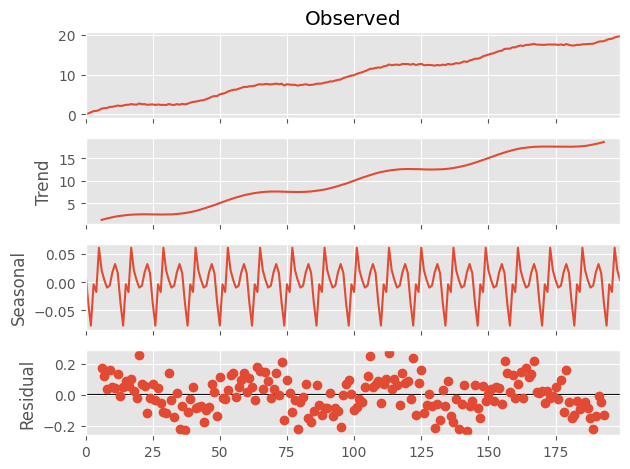

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición de la serie temporal
data = additive_series
result = seasonal_decompose(data, model='additive', period=12)  # period es el número de puntos en un ciclo estacional

# Visualizar la descomposición
result.plot()
plt.show()

## Descomposición: Tendencia

In [ ]:
df = pd.DataFrame(additive_series, columns=['Value'])
df.head()

,Value
0,0.049671
1,0.211507
2,0.513459
3,0.820428
4,0.858338


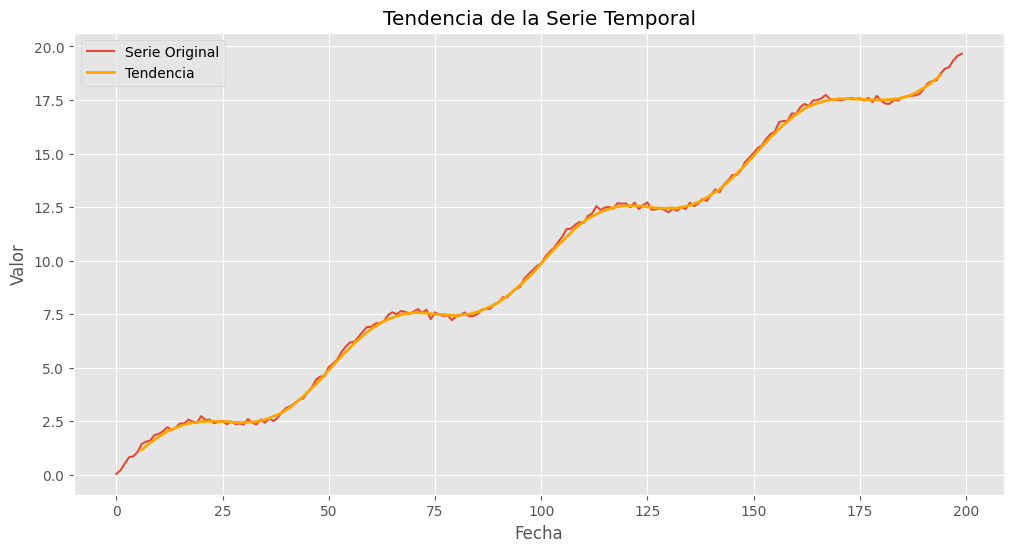

In [ ]:
# Extraer la tendencia usando un promedio móvil
window_size = 12 # Tamaño de la ventana para el promedio móvil
df['Tendencia'] = df['Value'].rolling(window=window_size, center=True).mean()

# Visualizar la tendencia
plt.figure(figsize=(12, 6))
plt.plot(df['Value'], label='Serie Original')
plt.plot(df['Tendencia'], label='Tendencia', color='Orange', linewidth=2)
plt.title('Tendencia de la Serie Temporal')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

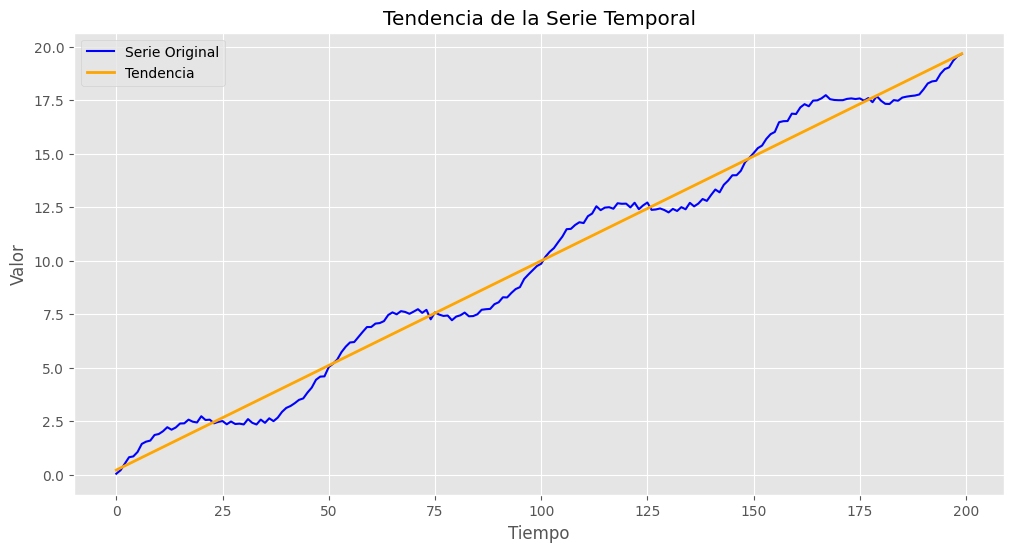

In [ ]:
# Descomposición de Tendencia con Regresión Lineal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Crear una columna con índices temporales (0, 1, 2, ...)
df['Time'] = np.arange(len(df))

# Preparar los datos para la regresión
X = df[['Time']]  # Variable independiente (tiempo)
y = df['Value']   # Variable dependiente (valor)

# Ajustar un modelo de regresión lineal
model = LinearRegression()
model.fit(X, y)

# Predecir la tendencia usando el modelo de regresión
df['Tendencia_Reg'] = model.predict(X)

# Visualizar la serie original y la tendencia
plt.figure(figsize=(12, 6))
plt.plot(df['Value'], label='Serie Original', color='blue')
plt.plot(df['Tendencia_Reg'], label='Tendencia', color='orange', linewidth=2)
plt.title('Tendencia de la Serie Temporal')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

##  Descomposición: Estacionalidad

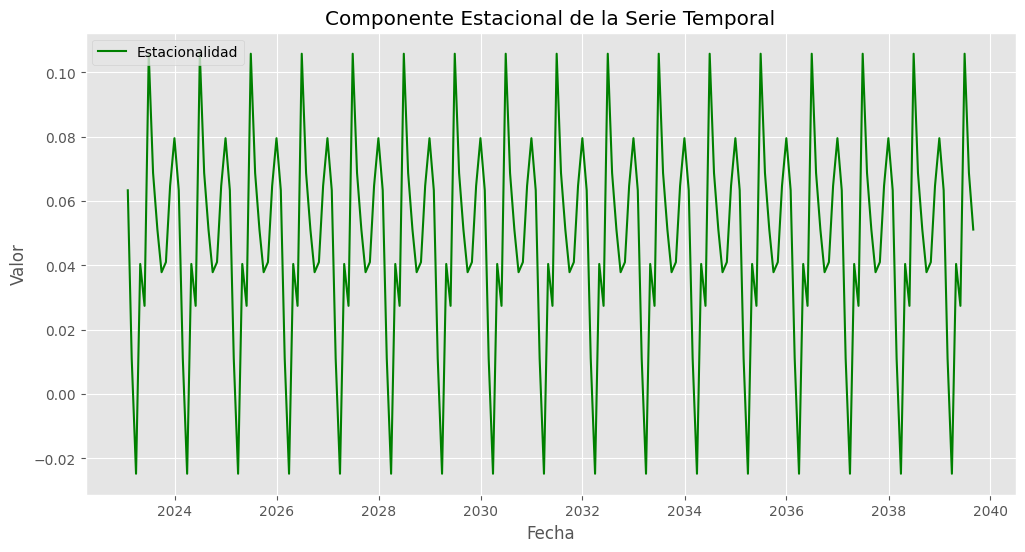

In [ ]:
# Restar la tendencia para obtener la serie desestacionalizada
df['Desestacionalizada'] = df['Value'] - df['Tendencia']

# Asignamos un periodo Temporal a la serie
df.index = pd.date_range(start='2023-01-01', periods=len(df), freq='ME')

# Calcular la estacionalidad (promedio por período estacional)
period = 6  # Período estacional (por ejemplo, 12 meses)
seasonal_components = df['Desestacionalizada'].groupby(df.index.month).mean()  # Agrupar por mes
df['Estacionalidad'] = df.index.month.map(seasonal_components)  # Mapear la estacionalidad a la serie

# Visualizar la estacionalidad
plt.figure(figsize=(12, 6))
plt.plot(df['Estacionalidad'], label='Estacionalidad', color='green')
plt.title('Componente Estacional de la Serie Temporal')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

## Descomposición: Residuo

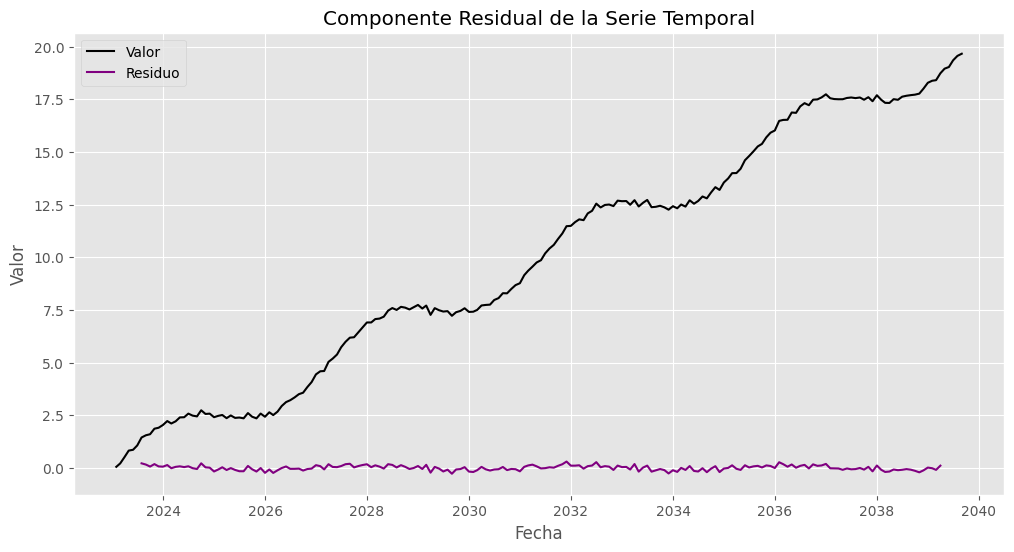

In [ ]:
# Calcular el residuo
df['Residuo'] = df['Value'] - df['Tendencia'] - df['Estacionalidad']

# Visualizar el residuo
plt.figure(figsize=(12, 6))
plt.plot(df['Value'], label='Valor', color='black')
plt.plot(df['Residuo'], label='Residuo', color='purple')
plt.title('Componente Residual de la Serie Temporal')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

# Autcorrelación y Autocorrelación Parcial

# ACF y PACF: ¿Qué son y por qué son importantes?

En el análisis de series temporales, la ACF (Función de Autocorrelación) y la PACF (Función de Autocorrelación Parcial) son herramientas fundamentales para entender las relaciones dentro de los datos.

---

## 1. ¿Qué es la ACF (Función de Autocorrelación)?
La ACF mide la correlación entre los valores de la serie temporal en diferentes retardos (lags).

**En otras palabras:**  
La ACF responde a la pregunta:  
*"¿Qué tan relacionadas están las observaciones actuales con las pasadas en un intervalo de tiempo específico?"*

- Los valores de la ACF están en el rango de \([-1, 1]\).
- Muestra el grado de dependencia entre los valores de la serie.

**Ejemplo de uso:**
- Identificar si la serie tiene un patrón estacional o tendencia.
- Determinar el parámetro \( q \) en un modelo ARIMA (orden del componente de media móvil).

---

## 2. ¿Qué es la PACF (Función de Autocorrelación Parcial)?
La PACF mide la correlación entre una observación y un retardo específico, eliminando la influencia de los retardos intermedios.

**En otras palabras:**  
La PACF responde a la pregunta:  
*"¿Qué tan fuerte es la relación entre el valor actual y un retardo específico, sin interferencia de los retardos entre ellos?"*

- Se utiliza para identificar relaciones directas, no indirectas, entre los valores de la serie.

**Ejemplo de uso:**
- Determinar el parámetro \( p \) en un modelo ARIMA (orden del componente autorregresivo).

---

## 3. ¿Para qué sirven la ACF y la PACF?
Estas funciones ayudan a:
- **Diagnosticar patrones en la serie:** Identificar si hay dependencia temporal, estacionalidad o ruido aleatorio.
- **Ajustar modelos ARIMA:**  
  - ACF: Para determinar \( q \) (componente de media móvil).  
  - PACF: Para determinar \( p \) (componente autorregresivo).
- **Validar estacionariedad:** Una ACF con un decaimiento lento puede indicar una serie no estacionaria.

---

## 4. ¿Por qué son importantes?
La ACF y la PACF son cruciales porque:
- **Facilitan la selección de modelos:** Proveen una guía visual para identificar los órdenes \( p \) y \( q \) en ARIMA.
- **Simplifican la interpretación de las relaciones temporales:** Permiten descomponer las dependencias directas (PACF) e indirectas (ACF).
- **Mejoran el análisis predictivo:** Identificar patrones correctos permite construir modelos más precisos.

---

## 5. ¿Cómo se interpretan?
- **ACF:**
  - Picos significativos en lags altos: Puede indicar estacionalidad o tendencia.
  - Decaimiento rápido a cero: Indica ruido blanco.
- **PACF:**
  - Pocos picos significativos iniciales: Indican el orden \( p \) del modelo ARIMA.




## ACF y PACF: Graficando sin Estacionar

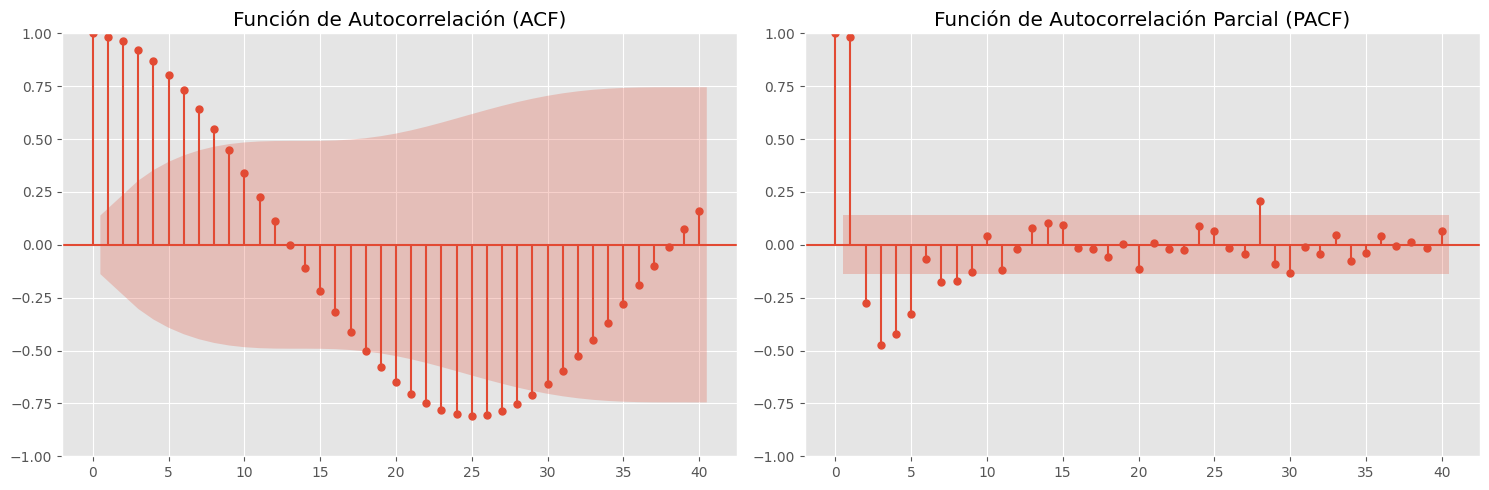

In [ ]:
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

data_m = pd.DataFrame({'Value': multiplicative_series})
data_m['time'] = range(len(data_m))



# Calcular y graficar la ACF
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(data_m['Value'], lags=40, ax=axes[0]) # Ajusta el número de lags si es necesario
axes[0].set_title('Función de Autocorrelación (ACF)')


# Calcular y graficar la PACF
plot_pacf(data_m['Value'], lags=40, ax=axes[1]) # Ajusta el número de lags si es necesario
axes[1].set_title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()
plt.show()

# ¿Por qué es importante diferenciar una serie temporal?

La diferenciación es una técnica clave en el análisis de series temporales, especialmente cuando trabajamos con datos no estacionarios. A continuación, se explican las razones principales:

## 1. Para hacer la serie **estacionaria**
La mayoría de los modelos estadísticos, como ARIMA, y herramientas como las funciones ACF y PACF, requieren que la serie temporal sea estacionaria. Si la serie tiene una tendencia o varianza que cambia con el tiempo, los resultados pueden ser inexactos o engañosos.

**Ejemplo:**
- Serie sin diferenciar: Puede mostrar una tendencia creciente o decreciente.
- Serie diferenciada: Elimina la tendencia y estabiliza las propiedades estadísticas.

---

## 2. Para mejorar la interpretación de ACF y PACF
Las gráficas de autocorrelación (ACF) y autocorrelación parcial (PACF) ayudan a determinar los parámetros \(p\) y \(q\) de un modelo ARIMA. Si la serie no es estacionaria:
- La ACF puede mostrar un **decaimiento lento** en lugar de cortarse después de algunos retardos (lags).
- La PACF puede mostrar picos confusos debido a la tendencia.

**Con una serie diferenciada, es más fácil identificar patrones significativos.**

---

## 3. Para evitar resultados estadísticos erróneos
Los modelos ajustados a series no estacionarias pueden:
- Producir coeficientes no significativos.
- Generar predicciones erráticas.
- No capturar correctamente la dinámica de los datos.

La diferenciación elimina las tendencias no deseadas y permite al modelo centrarse en las relaciones subyacentes de la serie.

---

## 4. ¿Cómo se diferencia una serie?
La diferenciación calcula la diferencia entre un valor actual y el anterior:

\[
y'_t = y_t - y_{t-1}
\]

Esto transforma la serie original en una versión donde las tendencias han sido eliminadas.

---

## 5. ¿Cuándo es suficiente una diferenciación?
Puedes verificar si la serie es estacionaria después de diferenciarla:
1. Usando pruebas como la **prueba Dickey-Fuller aumentada (ADF)**.
2. Analizando las gráficas ACF y PACF para patrones claros.

En algunos casos, una segunda diferenciación puede ser necesaria, aunque esto es menos común.




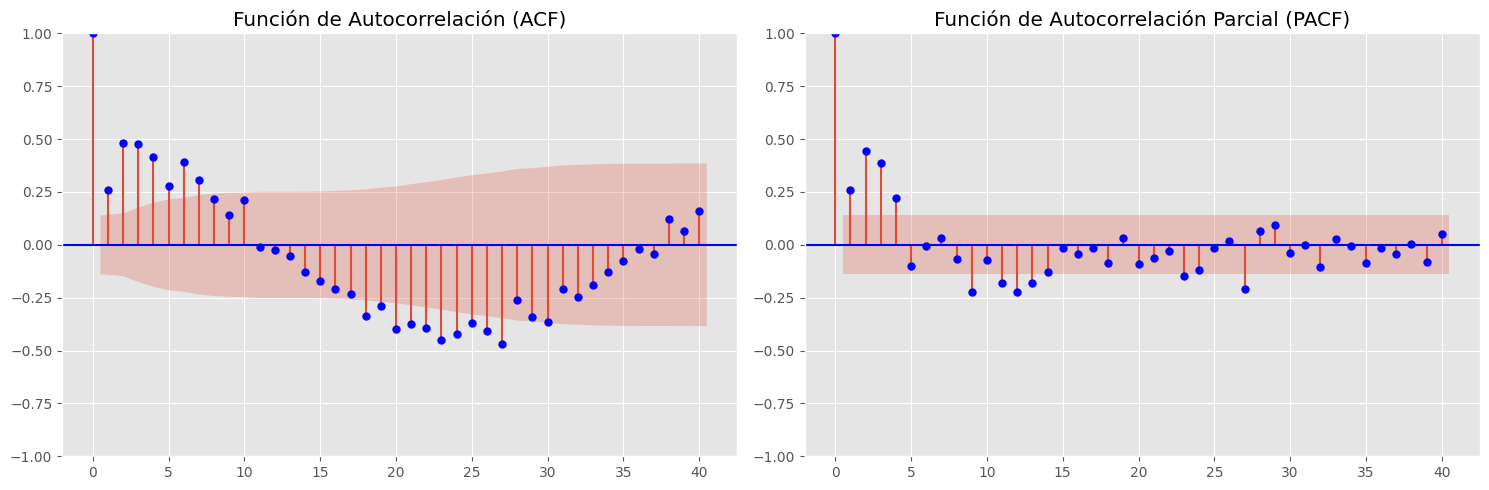

In [ ]:
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Crear un DataFrame con la serie multiplicativa
data_m = pd.DataFrame({'Value': multiplicative_series})
data_m['time'] = range(len(data_m))

# Diferenciar la serie para eliminar tendencias
data_m['Differenced'] = data_m['Value'].diff().dropna()

# Graficar ACF y PACF de la serie diferenciada
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Calcular y graficar la ACF
plot_acf(data_m['Differenced'].dropna(), lags=40, ax=axes[0], color='blue')
axes[0].set_title('Función de Autocorrelación (ACF)')

# Calcular y graficar la PACF
plot_pacf(data_m['Differenced'].dropna(), lags=40, ax=axes[1], color='blue')
axes[1].set_title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()
plt.show()


## Diferenciación: ¿La serie ya es estacionaria?

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Prueba Dickey-Fuller sobre la serie diferenciada
result = adfuller(data_m['Differenced'].dropna())

# Mostrar resultados
print("Estadístico de la prueba ADF:", result[0])
print("p-valor:", result[1])
print("Valores críticos:")
for key, value in result[4].items():
    print(f"  {key}: {value}")

# Interpretar el resultado
if result[1] <= 0.05:
    print("La serie es estacionaria (rechazamos la hipótesis nula).")
else:
    print("La serie no es estacionaria (no podemos rechazar la hipótesis nula).")

Estadístico de la prueba ADF: -7.868951059189012
p-valor: 5.0454183736203e-12
Valores críticos:
  1%: -3.466598080268425
  5%: -2.8774669520682674
  10%: -2.5752604356654425
La serie es estacionaria (rechazamos la hipótesis nula).


## Si hace falta diferenciar de nuevo...

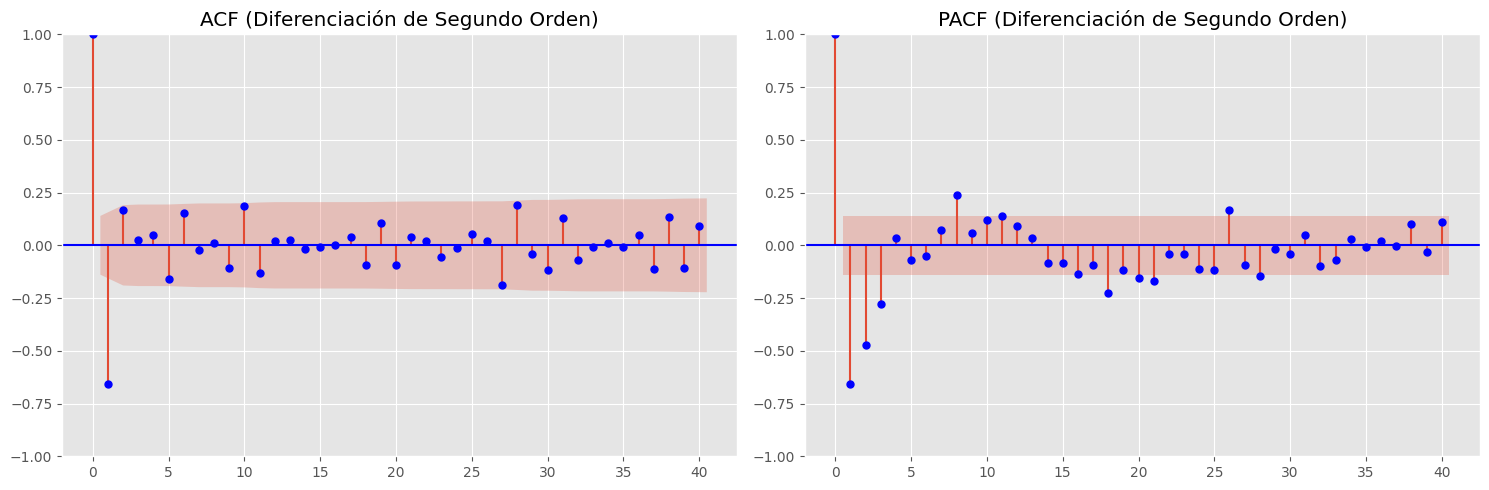

In [ ]:
data_m['Differenced_2'] = data_m['Differenced'].diff().dropna()

# Verificar la nueva ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(data_m['Differenced_2'].dropna(), lags=40, ax=axes[0], color='blue')
axes[0].set_title('ACF (Diferenciación de Segundo Orden)')

plot_pacf(data_m['Differenced_2'].dropna(), lags=40, ax=axes[1], color='blue')
axes[1].set_title('PACF (Diferenciación de Segundo Orden)')

plt.tight_layout()
plt.show()

# Guía para interpretar gráficos ACF y PACF para configurar modelos ARIMA y SARIMA

## **1. ¿Qué son ACF y PACF?**
### **Función de Autocorrelación (ACF):**
La ACF mide la correlación entre los valores de la serie y sus valores retardados (lags). Es útil para identificar patrones de dependencia temporal en los datos.

- **En ARIMA:**
  - Ayuda a determinar el orden \(q\) (componente de media móvil, MA).
  - En modelos MA, la ACF generalmente muestra un corte claro después de un cierto número de lags.

### **Función de Autocorrelación Parcial (PACF):**
La PACF mide la correlación entre un valor de la serie y sus lags, eliminando la influencia de los lags intermedios.

- **En ARIMA:**
  - Ayuda a determinar el orden \(p\) (componente autorregresiva, AR).
  - En modelos AR, la PACF generalmente muestra un corte claro después de un cierto número de lags.

---

## **2. Parámetros de ARIMA**
Un modelo ARIMA se configura con tres parámetros principales: \(p\), \(d\), \(q\).
- **\(p\):** Orden de la parte autorregresiva (AR).
  - Determina cuántos valores pasados afectan el valor actual.
  - Identificado con picos significativos en el gráfico PACF.

- **\(d\):** Diferenciación para hacer la serie estacionaria.
  - \(d\) es el número de veces que los datos deben diferenciarse para eliminar tendencias.
  - Confirmado con la prueba ADF o inspeccionando la ACF de la serie original (un decaimiento lento indica la necesidad de diferenciación).

- **\(q\):** Orden de la parte de media móvil (MA).
  - Determina cuántos errores pasados afectan el valor actual.
  - Identificado con picos significativos en el gráfico ACF.

---

## **3. Interpretando ACF y PACF para ARIMA**
### **Serie original (no diferenciada):**
- **ACF:**
  - Si muestra un decaimiento lento (cola larga), la serie no es estacionaria.
  - Es necesario diferenciar la serie (\(d\)).

- **PACF:**
  - Puede no ser clara si la serie no es estacionaria. Diferenciar primero.

### **Serie diferenciada (estacionaria):**
- **ACF:**
  - Picos significativos en los primeros lags indican \(q\) (orden de media móvil).
  - Un corte claro después de algunos lags sugiere el valor de \(q\).

- **PACF:**
  - Picos significativos en los primeros lags indican \(p\) (orden autorregresivo).
  - Un corte claro después de algunos lags sugiere el valor de \(p\).

---

## **4. Extensión a SARIMA**
Un modelo SARIMA agrega componentes estacionales a ARIMA mediante los parámetros estacionales \((P, D, Q, s)\):
- **\(P\):** Orden autorregresivo estacional.
  - Identificado con picos significativos en el PACF estacional.
- **\(D\):** Diferenciación estacional.
  - Determina cuántas veces diferenciar para eliminar estacionalidad.
- **\(Q\):** Orden de media móvil estacional.
  - Identificado con picos significativos en el ACF estacional.
- **\(s\):** Periodo estacional (frecuencia de la estacionalidad, ej., 12 para datos mensuales o 7 para datos semanales).

### **Interpretación de ACF y PACF para SARIMA:**
1. Inspecciona los gráficos ACF y PACF estacionales (multiplicando los lags por \(s\), el periodo estacional).
2. Sigue las mismas reglas que en ARIMA, pero enfocándote en los patrones recurrentes que ocurren en intervalos estacionales.

---

## **5. Pasos para configurar un modelo ARIMA o SARIMA**
1. **Revisar estacionariedad:**
   - Inspecciona el gráfico ACF para detectar decaimiento lento.
   - Si la serie no es estacionaria, diferencia los datos (\(d > 0\)).

2. **Determinar \(p\) y \(q\):**
   - Usa PACF para identificar \(p\): Corte en el gráfico PACF.
   - Usa ACF para identificar \(q\): Corte en el gráfico ACF.

3. **Agregar componentes estacionales (para SARIMA):**
   - Identifica patrones estacionales con ACF y PACF estacionales.
   - Configura \(P\), \(D\), \(Q\), y \(s\) basándote en los gráficos y el periodo estacional.

---

## **6. Ejemplo práctico:**
### Interpretación de ACF y PACF:
1. **ACF de una serie estacionaria:**
   - Picos significativos en lag 1 y 2 -> \(q=2\).
   - Corte claro después del lag 2.

2. **PACF de una serie estacionaria:**
   - Picos significativos en lag 1 -> \(p=1\).
   - Corte claro después del lag 1.

### Configuración de ARIMA:
- **Parámetros:** \(ARIMA(1, 1, 2)\).
- **Interpretación:**
  - \(p=1\): Un valor pasado afecta directamente.
  - \(d=1\): Serie diferenciada una vez para estacionariedad.
  - \(q=2\): Dos errores pasados afectan directamente.
